# Telco Customer Churn Prediction

## Project Overview

The goal of this project is to predict customer churn for a telecommunications company.

Customer churn means that a customer stops using the company's services. A churn prediction model can help the company identify customers at high risk of leaving and target them with retention actions.

## Dataset

The dataset used in this project is the Telco Customer Churn dataset from Kaggle. It contains customer demographic information, account details, subscribed services, and churn status.


In [117]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    precision_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [118]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [119]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [120]:
csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(csv_file)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [122]:
mask = (
    pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
)

df.loc[mask]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## Data Preprocessing

In this section, I clean the data, encode categorical variables, split the dataset into train, validation, and test sets, and scale numerical features.

The test set is kept separate until the final evaluation to avoid data leakage.

In [123]:
df.drop(columns=["customerID"], inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


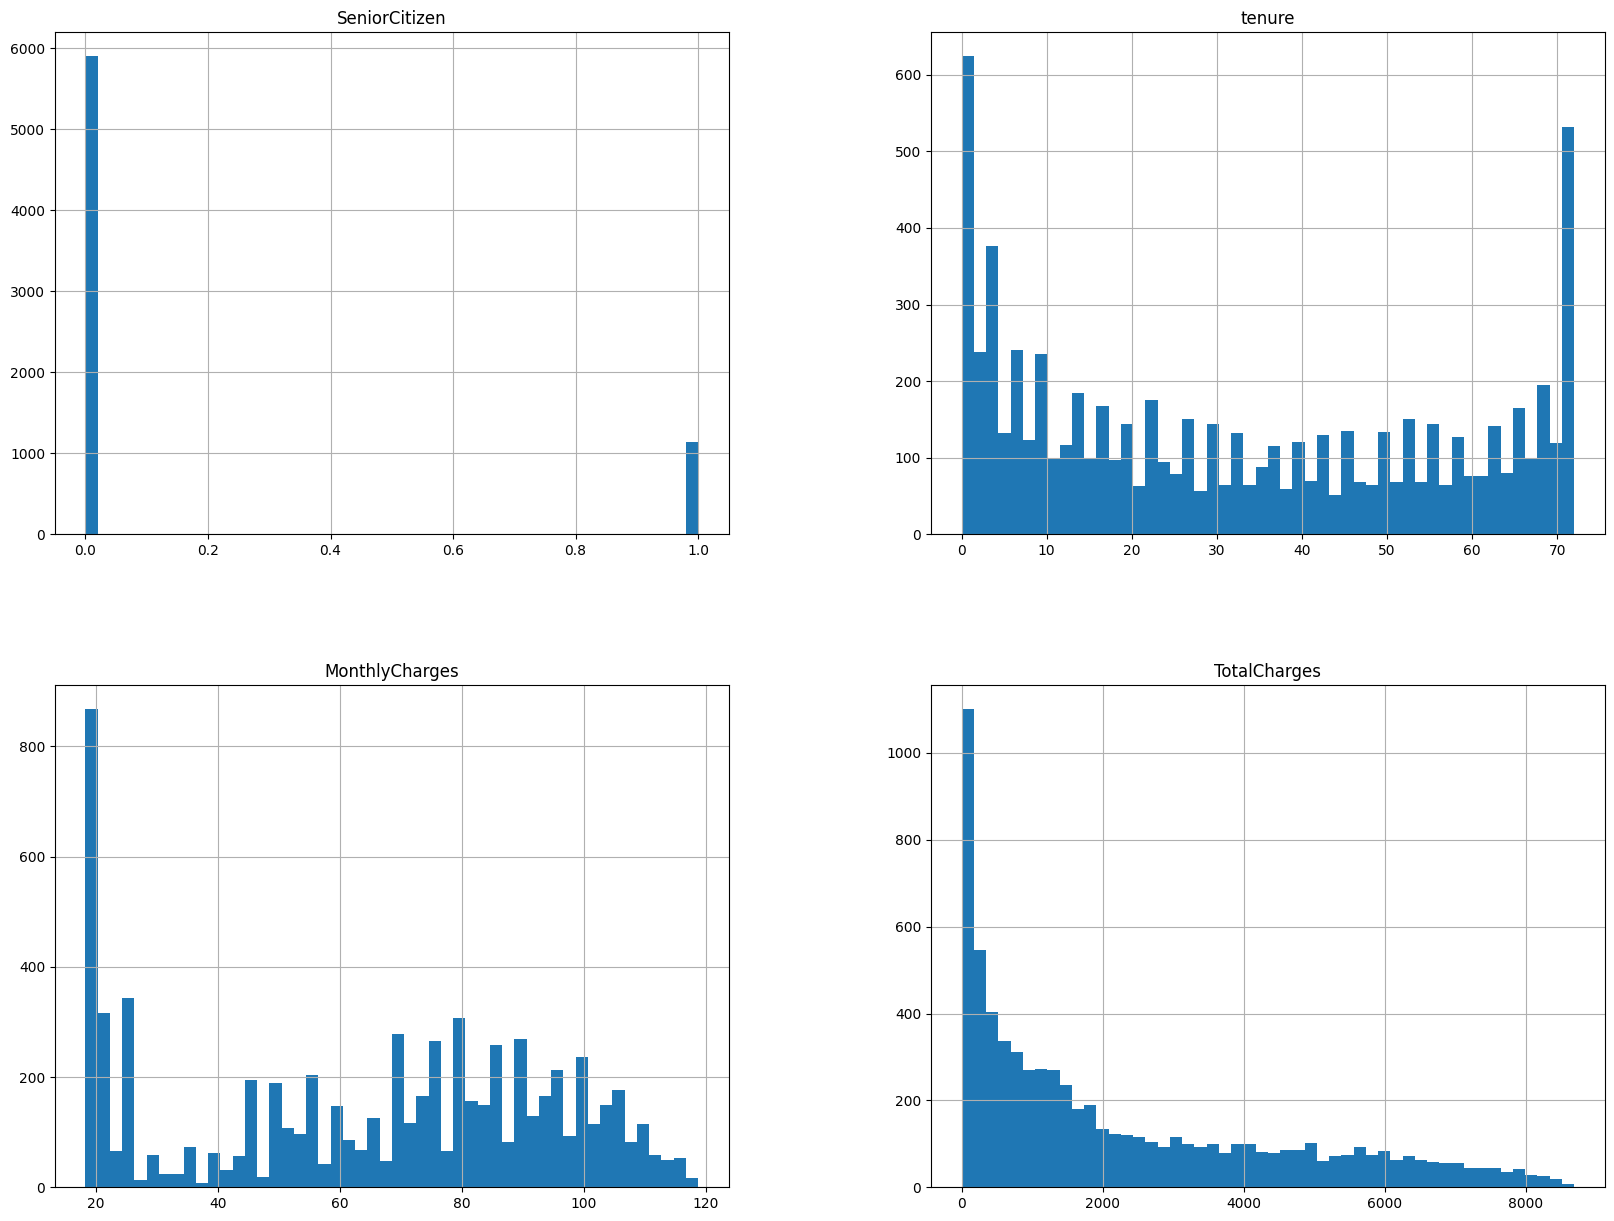

In [124]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

In [125]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove("SeniorCitizen")
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [126]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [127]:
for cat in cat_cols:
  print(f"{cat}: {df[cat].unique()}")


gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


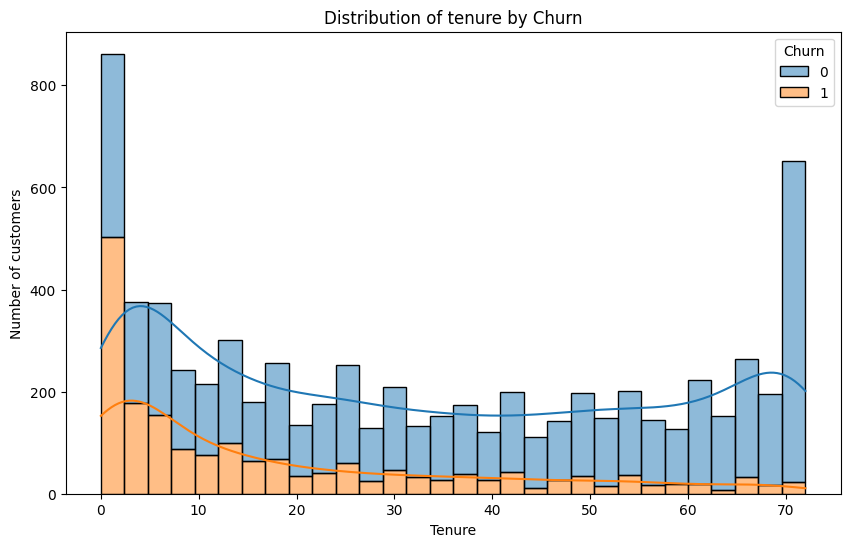

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Distribution of tenure by Churn")
plt.xlabel("Tenure")
plt.ylabel("Number of customers")
plt.show()

In [129]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 20, float("inf")],
    labels=["<6", "6-20", "20+"]
)

In [130]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
hot_encoder = OneHotEncoder()

cat_cols_le = ['Partner','Dependents','PhoneService',"PaperlessBilling","tenure_group", "Churn"]
cat_cols_hot = [label for label in cat_cols if label not in cat_cols_le]

for cat in cat_cols_le:
  df[cat] = le.fit_transform(df[cat])

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols_hot,
    drop_first=True,
    dtype=int
)

In [131]:
features = ["tenure", "tenure_group", "Churn"]

corr_matrix = df[features].corr()
corr_matrix

,tenure,tenure_group,Churn
tenure,1.000000,-0.826128,-0.352229
tenure_group,-0.826128,1.000000,0.348587
Churn,-0.352229,0.348587,1.000000


In [132]:
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [133]:
from sklearn.model_selection import train_test_split

df_encoded = df_encoded.drop(columns=["tenure"])
num_cols.remove("tenure")

X = df_encoded.drop(columns=["Churn"])
y = df["Churn"]

# First, we set aside the test set: 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (5634, 30) (5634,)
Test: (1409, 30) (1409,)


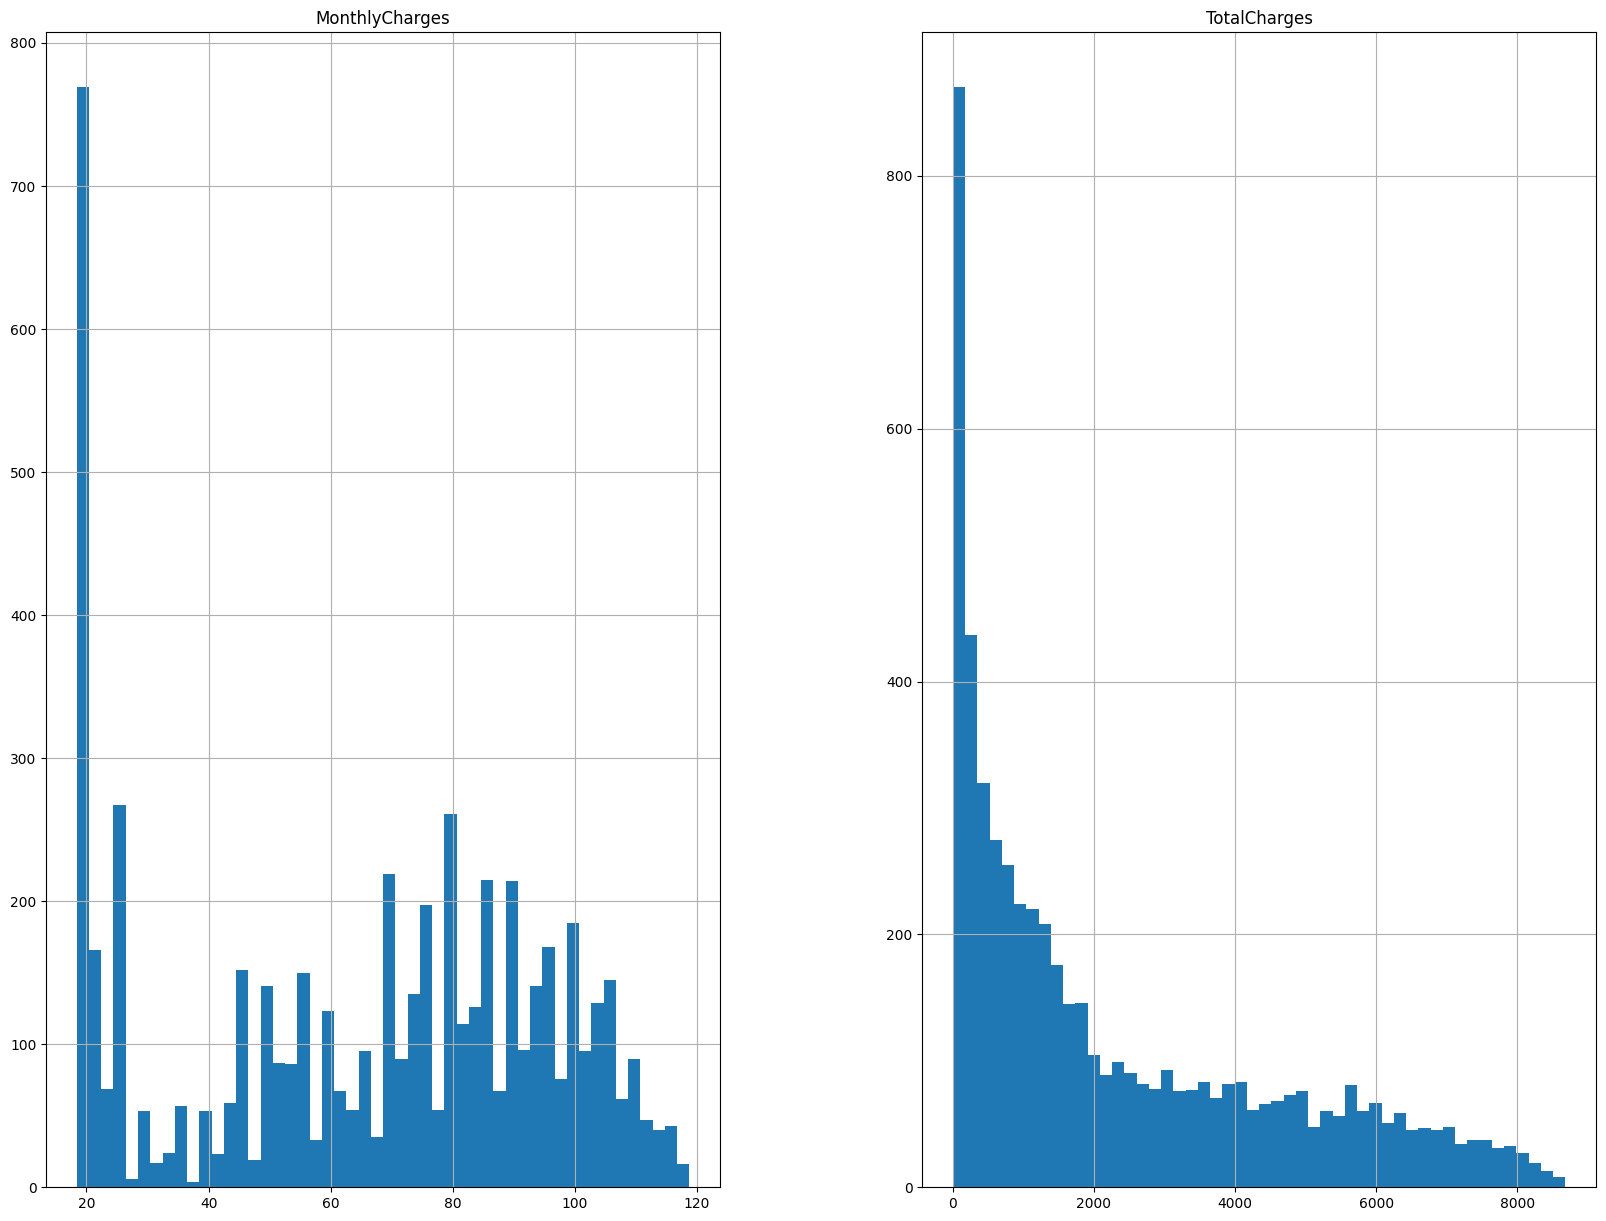

In [134]:
X_train[num_cols].hist(bins=50, figsize=(20,15))
plt.show()

In [135]:
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler


scaler = MinMaxScaler()
pt = PowerTransformer(method='yeo-johnson', standardize=False)

X_train[['TotalCharges']] = pt.fit_transform(X_train[['TotalCharges']])
X_test[['TotalCharges']] = pt.transform(X_test[['TotalCharges']])


X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


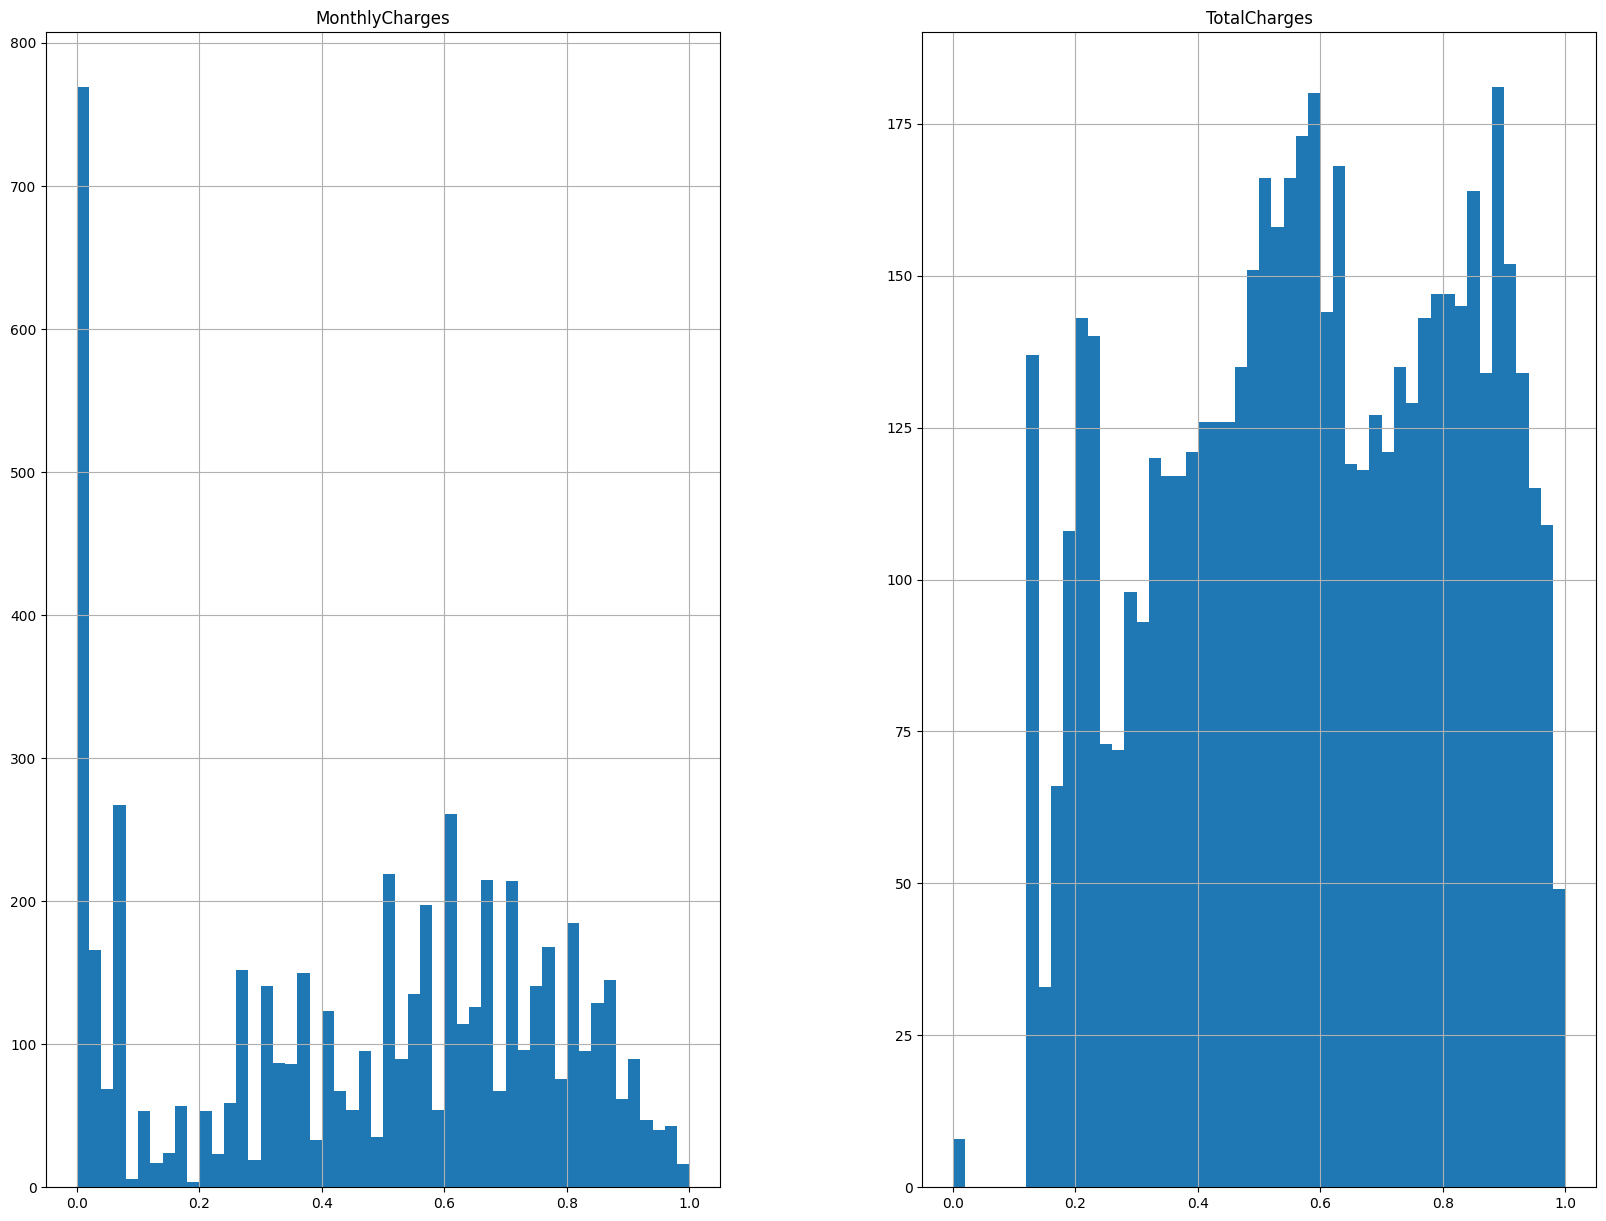

In [136]:
X_train[num_cols].hist(bins=50, figsize=(20,15))
plt.show()

In [137]:
X_train.info()
y_train.value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          5634 non-null   int64  
 1   Partner                                5634 non-null   int64  
 2   Dependents                             5634 non-null   int64  
 3   PhoneService                           5634 non-null   int64  
 4   PaperlessBilling                       5634 non-null   int64  
 5   MonthlyCharges                         5634 non-null   float64
 6   TotalCharges                           5634 non-null   float64
 7   tenure_group                           5634 non-null   int64  
 8   gender_Male                            5634 non-null   int64  
 9   MultipleLines_No phone service         5634 non-null   int64  
 10  MultipleLines_Yes                      5634 non-null   int64  
 11  Intern

,count
Churn,
0,4139
1,1495


In [138]:
from sklearn.utils import shuffle

train_df = X_train.copy()
train_df["Churn"] = y_train.values


df_class_0 = train_df[train_df["Churn"] == 0]
df_class_1 = train_df[train_df["Churn"] == 1]

print(df_class_0.shape)
print(df_class_1.shape)

n_to_sample = len(df_class_0) - len(df_class_1)

df_class_1_over = pd.concat([
    df_class_1,
    df_class_1.sample(
        n=n_to_sample,
        replace=True,
        random_state=42
    )
])

train_balanced = pd.concat([df_class_0, df_class_1_over])

train_balanced = shuffle(
    train_balanced,
    random_state=42
).reset_index(drop=True)

X_train_balanced = train_balanced.drop(columns="Churn")
y_train_balanced = train_balanced["Churn"]

print(X_train_balanced.shape)
print(y_train_balanced.shape)

(4139, 31)
(1495, 31)
(8278, 30)
(8278,)


## Modeling

I compare three models:

- Logistic Regression,
- Neural Network,
- XGBoost.

Because churn is an imbalanced classification problem, I evaluate the models using ROC-AUC, PR-AUC, precision, recall, and F1-score.

In [139]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

nn = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

In [140]:

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
nn.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [141]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = nn.fit(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6069 - auc: 0.6768 - loss: 0.6576 - val_accuracy: 0.7697 - val_auc: 0.8377 - val_loss: 0.5713
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - auc: 0.7960 - loss: 0.5627 - val_accuracy: 0.7834 - val_auc: 0.8492 - val_loss: 0.5014
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7486 - auc: 0.8172 - loss: 0.5260 - val_accuracy: 0.7794 - val_auc: 0.8528 - val_loss: 0.4786
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7523 - auc: 0.8231 - loss: 0.5163 - val_accuracy: 0.7802 - val_auc: 0.8557 - val_loss: 0.4714
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7543 - auc: 0.8324 - loss: 0.5041 - val_accuracy: 0.7802 - val_auc: 0.8572 - val_loss: 0.4681
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7629 - auc: 0.8350 - loss: 0.5001 - val_accuracy: 0.7794 - val_auc: 0.8587 - val_loss: 0.4654
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 

In [142]:
def evaluate_model(model, X_test, y_test, threshold):
    y_proba = model.predict(X_test).ravel()
    y_test_pred = (y_proba >= 0.5).astype(int)

    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("PR-AUC:", average_precision_score(y_test, y_proba))

    print("\nClassification report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_test_pred))

def evaluate_model(model_name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba)
    }

    print(f"Model: {model_name}")
    print(f"Threshold: {threshold}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    return metrics

In [143]:
nn_test_proba = nn.predict(X_test).ravel()

nn_metrics = evaluate_model(
    model_name="Neural Network",
    y_true=y_test,
    y_proba=nn_test_proba,
    threshold=threshold
)

nn_metrics

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model: Neural Network
Threshold: 0.55

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


Confusion matrix:
[[787 248]
 [ 93 281]]


{'Model': 'Neural Network',
 'Threshold': np.float64(0.55),
 'Accuracy': 0.7579843860894251,
 'Precision': 0.5311909262759924,
 'Recall': 0.7513368983957219,
 'F1': 0.6223698781838317,
 'ROC-AUC': np.float64(0.8433852592420368),
 'PR-AUC': np.float64(0.6525362869592923)}

In [144]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

log_test_proba = log_model.predict_proba(X_test)[:, 1]

log_metrics = evaluate_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_proba=log_test_proba,
    threshold=0.5
)

log_metrics

Model: Logistic Regression
Threshold: 0.5

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Confusion matrix:
[[754 281]
 [ 79 295]]


{'Model': 'Logistic Regression',
 'Threshold': 0.5,
 'Accuracy': 0.7444996451383961,
 'Precision': 0.5121527777777778,
 'Recall': 0.7887700534759359,
 'F1': 0.6210526315789474,
 'ROC-AUC': np.float64(0.8461882249606034),
 'PR-AUC': np.float64(0.6572197907541031)}

In [145]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

param_dist = {
    "n_estimators": [100, 200, 300, 500, 800],
    "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 2, 3, 5, 7, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.01, 0.05, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.001, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring="average_precision",   # PR-AUC
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best score:", search.best_score_)
print("Best params:")
print(search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best score: 0.6707561412710229
Best params:
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.001, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 1.0}


In [146]:
xgb_model = search.best_estimator_

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = evaluate_model(
    model_name="XGBoost",
    y_true=y_test,
    y_proba=xgb_test_proba,
)

xgb_metrics

Model: XGBoost
Threshold: 0.5

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.75      0.76      1409


Confusion matrix:
[[750 285]
 [ 73 301]]


{'Model': 'XGBoost',
 'Threshold': 0.5,
 'Accuracy': 0.7459190915542938,
 'Precision': 0.5136518771331058,
 'Recall': 0.8048128342245989,
 'F1': 0.6270833333333333,
 'ROC-AUC': np.float64(0.8460926399545325),
 'PR-AUC': np.float64(0.662507603945543)}

In [147]:
results_df = pd.DataFrame([
    log_metrics,
    nn_metrics,
    xgb_metrics
])

results_df = results_df.sort_values("PR-AUC", ascending=False)

results_df

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,XGBoost,0.50,0.745919,0.513652,0.804813,0.627083,0.846093,0.662508
0,Logistic Regression,0.50,0.744500,0.512153,0.788770,0.621053,0.846188,0.657220
1,Neural Network,0.55,0.757984,0.531191,0.751337,0.622370,0.843385,0.652536


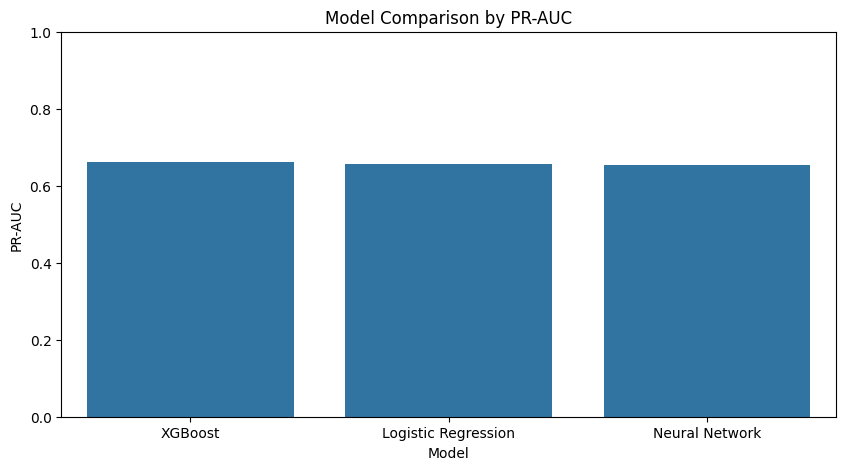

In [148]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="PR-AUC")
plt.title("Model Comparison by PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.show()

## Final Conclusions

The goal of this project was to predict customer churn based on customer account and service information.

The models were compared using several classification metrics. PR-AUC and recall are especially important because churn is the minority class and missing churned customers can be costly for the business.

In a real business scenario, the company could use the model to identify customers with a high churn risk and target them with retention campaigns, discounts, or personalized offers.

The final decision threshold should depend on business priorities:

- a lower threshold increases recall and catches more potential churners,
- a higher threshold increases precision and reduces unnecessary retention actions.